# Task B1: Image Reading, resizing, histogram equalization

a) Histogram and histogram equalization
- Compute and display the histogram of the grayscale image
- Apply histogram equalization to the grayscale image
- Compute and display the histogram of the equalize image
- 
(b) Resize the grayscale image to 150% of its original width and height.

(c) Display the following results:
- original image;
- grayscale image;
- resized grayscale image;
- histogram of the grayscale image;
- equalized grayscale image;
- histogram of the equalized grayscale image;
- grayscale image and equalized grayscale image side by side for comparison.

Text(0.5, 1.0, 'Grayscale image')

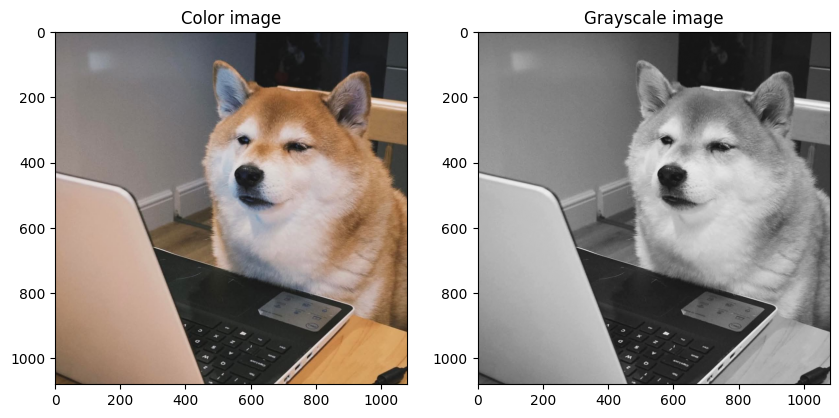

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("dog.jpg")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(10,5))

axes[0].imshow(image)
axes[0].set_title("Color image")

axes[1].imshow(gray, cmap="gray")
axes[1].set_title("Grayscale image")

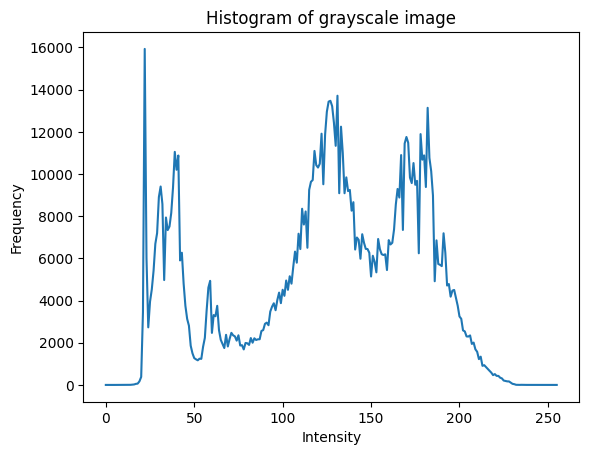

In [13]:
# Compute and display the histogram of the grayscale image
histg = cv2.calcHist([gray], [0], None, [256], [0, 256])
plt.plot(histg)
plt.title("Histogram of grayscale image")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.show()

Text(0.5, 1.0, 'Equalized grayscale image')

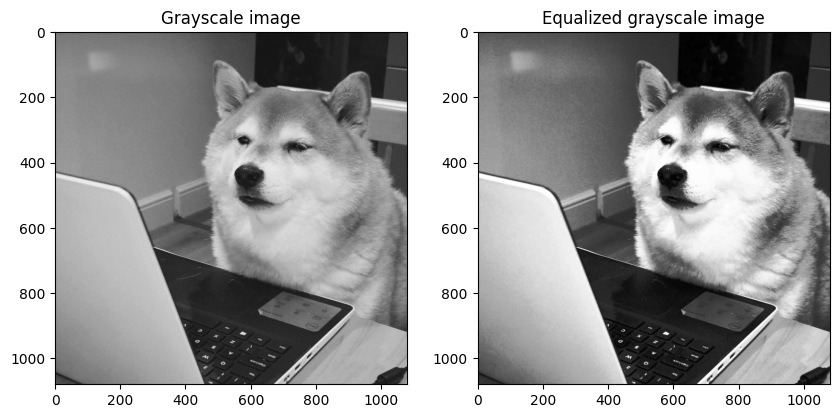

In [14]:
equalized = cv2.equalizeHist(gray)

fig, axes = plt.subplots(1, 2, figsize=(10,5))

axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Grayscale image")

axes[1].imshow(equalized, cmap="gray")
axes[1].set_title("Equalized grayscale image")

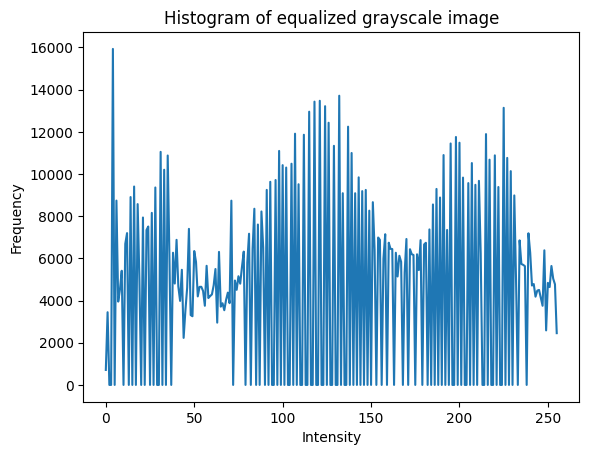

In [17]:
equalized_histg = cv2.calcHist([equalized], [0], None, [256], [0, 256])
plt.plot(equalized_histg)
plt.title("Histogram of equalized grayscale image")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.show()

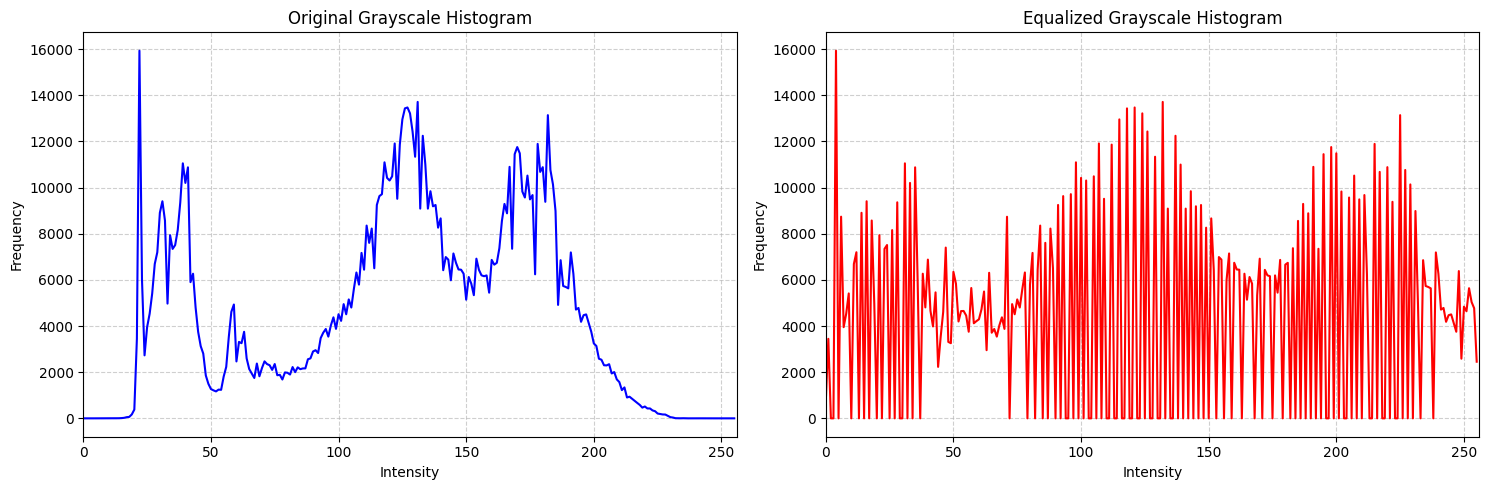

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(histg, color='blue')
axes[0].set_title("Original Grayscale Histogram")
axes[0].set_xlabel("Intensity")
axes[0].set_ylabel("Frequency")
axes[0].set_xlim([0, 256])
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(equalized_histg, color='red')
axes[1].set_title("Equalized Grayscale Histogram")
axes[1].set_xlabel("Intensity")
axes[1].set_ylabel("Frequency")
axes[1].set_xlim([0, 256])
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

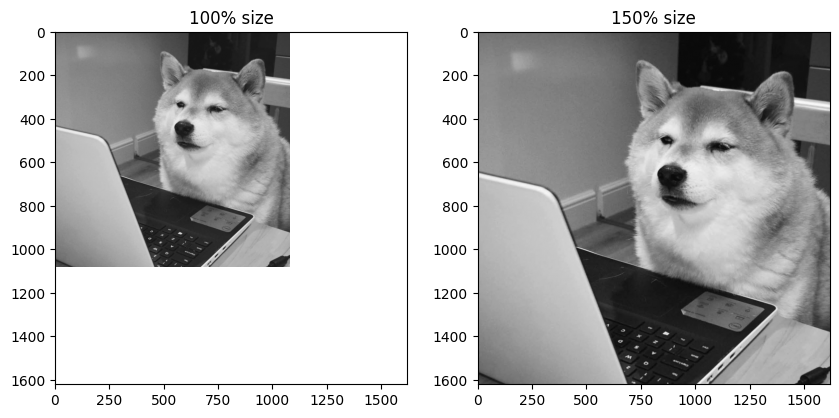

In [27]:
# Resized the image to 150%
resized = cv2.resize(gray, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_LINEAR)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(gray, cmap="gray")
axes[0].set_title("100% size")

axes[1].imshow(resized, cmap="gray")
axes[1].set_title("150% size")

height, width = resized.shape

for ax in axes:
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0) 

plt.show()

(d): Print the basic information of both the original image and the grayscale image, including:
- image size;
- number of channels;
- data type;
- minimum pixel value;
- maximum pixel value.

In [41]:
# Basic information
print(f"Image size (both) : Width = {image.shape[0]}, Length = {image.shape[1]}")
print(f"Number of channels (for color image): {image.shape[2]}")
print(f"Grayscale image properties: {gray.shape}")
print(f"Data type: {type(image)}, {type(gray)}")

Image size (both) : Width = 1080, Length = 1080
Number of channels (for color image): 3
Grayscale image properties: (1080, 1080)
Data type: <class 'numpy.ndarray'>, <class 'numpy.ndarray'>


In [42]:
def findMax(image):
    max = image[0][0]
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            if image[i][j] > max:
                max = image[i][j]
    return max

def findMin(image):
    min = image[0][0]
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            if image[i][j] < min:
                min = image[i][j]
    return min

print("Maximum pixel value of grayscale image: ", findMax(gray))
print("Minimum pixel value of grayscale image: ", findMin(gray))

Maximum pixel value of grayscale image:  242
Minimum pixel value of grayscale image:  1


In [45]:
print("Pixel values of color image:")
for i, channel_name in enumerate(["Red", "Green", "Blue"]):
    min_val = np.min(image[:, :, i])
    max_val = np.max(image[:, :, i])
    print(f"\t {channel_name} : Min: {min_val}, Max: {max_val}")

Pixel values of color image:
	 Red : Min: 0, Max: 253
	 Green : Min: 1, Max: 241
	 Blue : Min: 0, Max: 238


# Task B2: Brightness and Contrast adjustment
img_processed = a * f(x,y) + b

(a, b) = (1, 50), (1, -50), (1.5, 0), (0.5, 0)

- display the original and processed images;
- display the histogram of each processed image;
- compare the effects of different values of a and b;
- explain how a affects contrast and how b affects brightness.

In [81]:
def trans(image, a, b):
    trans_img = image.copy()
    for i in range(trans_img.shape[0]):
        for j in range(trans_img.shape[1]):
            s = a*int(trans_img[i][j]) + b
            if s > 255:
                s = 255
            elif s < 0:
                s = 0
            trans_img[i][j] = s
    return trans_img

def compare_histg(histg, histg_new):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].plot(histg, color='blue')
    axes[0].set_title("Original Grayscale Histogram")
    axes[0].set_xlabel("Intensity")
    axes[0].set_ylabel("Frequency")
    axes[0].set_xlim([0, 256])
    axes[0].grid(True, linestyle='--', alpha=0.6)
    
    axes[1].plot(histg_new, color='red')
    axes[1].set_title("Processed Grayscale Histogram")
    axes[1].set_xlabel("Intensity")
    axes[1].set_ylabel("Frequency")
    axes[1].set_xlim([0, 256])
    axes[1].grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

In [82]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("dog.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

Text(0.5, 1.0, 'Processed grayscale image')

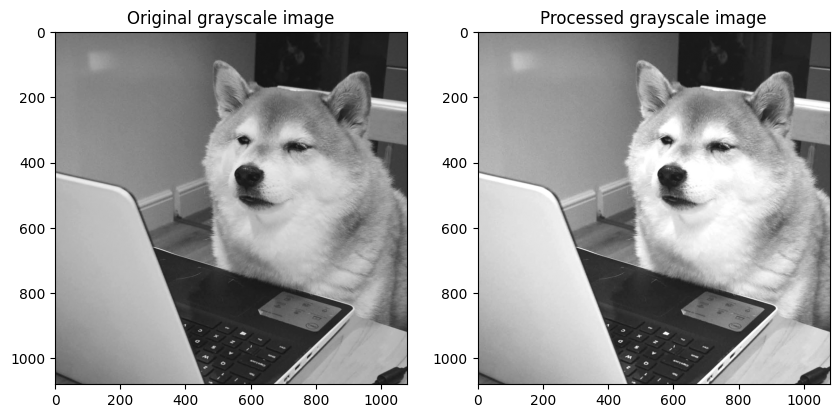

In [83]:
# a = 1, b = 50
trans_img = trans(image, 1, 50)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original grayscale image")

axes[1].imshow(trans_img, cmap="gray")
axes[1].set_title("Processed grayscale image")

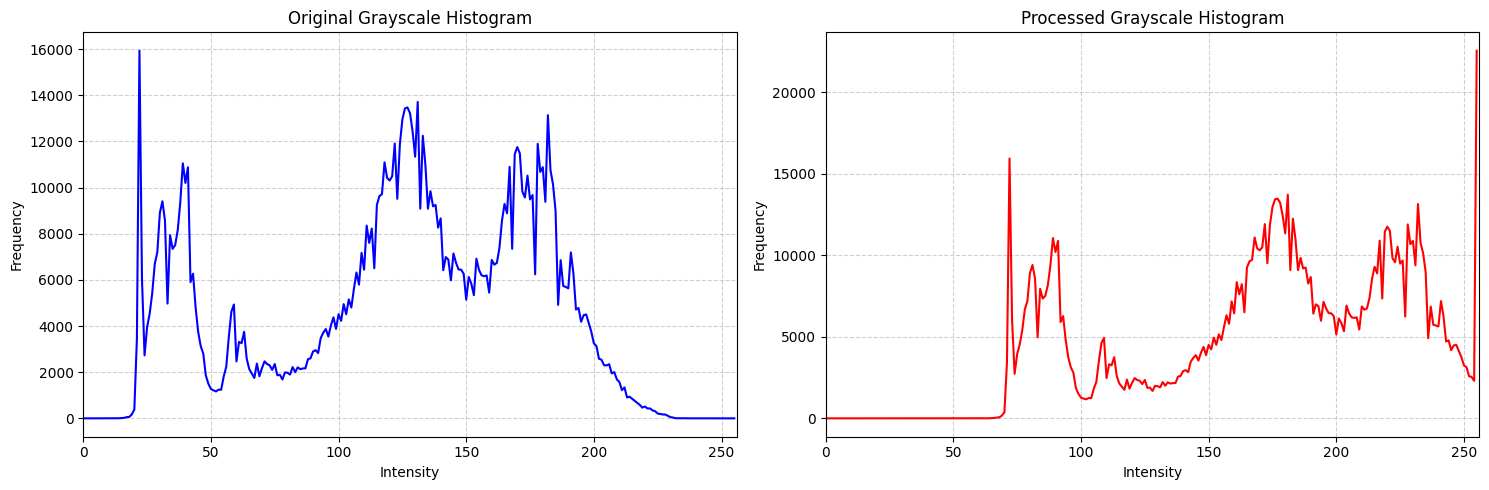

In [84]:
histg = cv2.calcHist([image], [0], None, [256], [0, 256])
histg_new = cv2.calcHist([trans_img], [0], None, [256], [0, 256])

compare_histg(histg, histg_new)

Text(0.5, 1.0, 'Processed grayscale image')

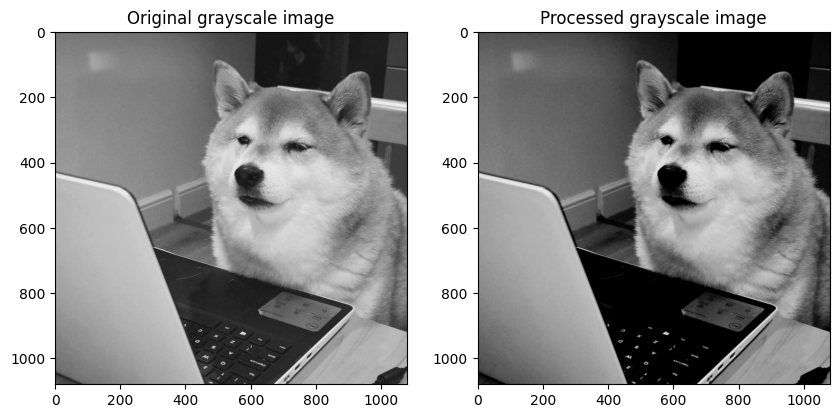

In [85]:
# a = 1, b = -50
trans_img = trans(image, 1, -50)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original grayscale image")

axes[1].imshow(trans_img, cmap="gray")
axes[1].set_title("Processed grayscale image")

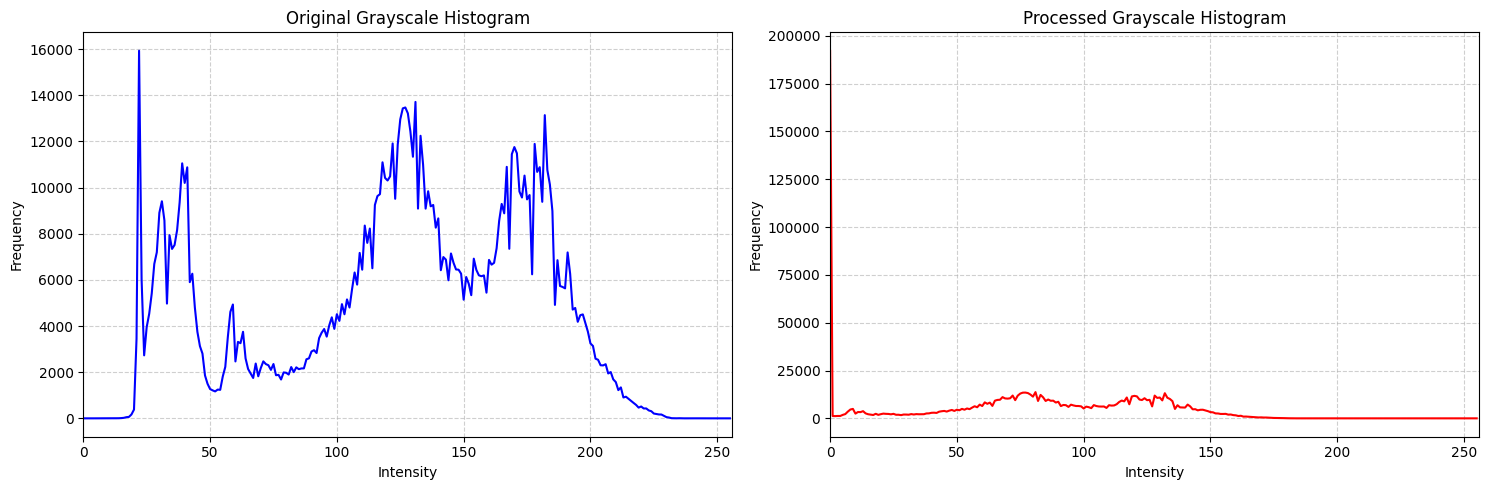

In [86]:
histg_new = cv2.calcHist([trans_img], [0], None, [256], [0, 256])

compare_histg(histg, histg_new)

Text(0.5, 1.0, 'Processed grayscale image')

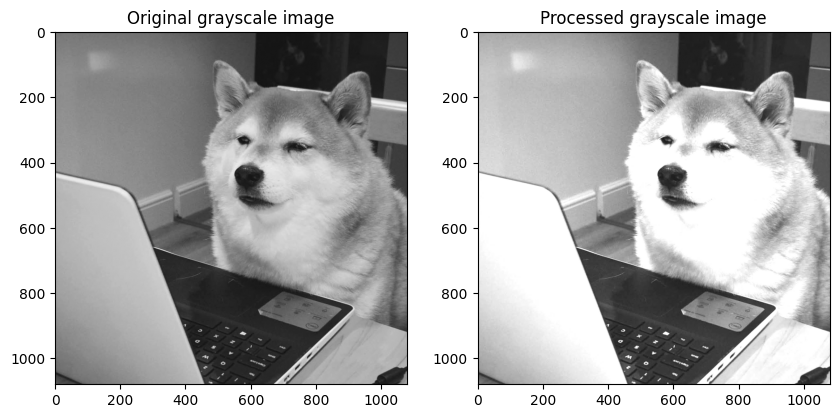

In [87]:
# a = 1.5, b = 0
trans_img = trans(image, 1.5, 0)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original grayscale image")

axes[1].imshow(trans_img, cmap="gray")
axes[1].set_title("Processed grayscale image")

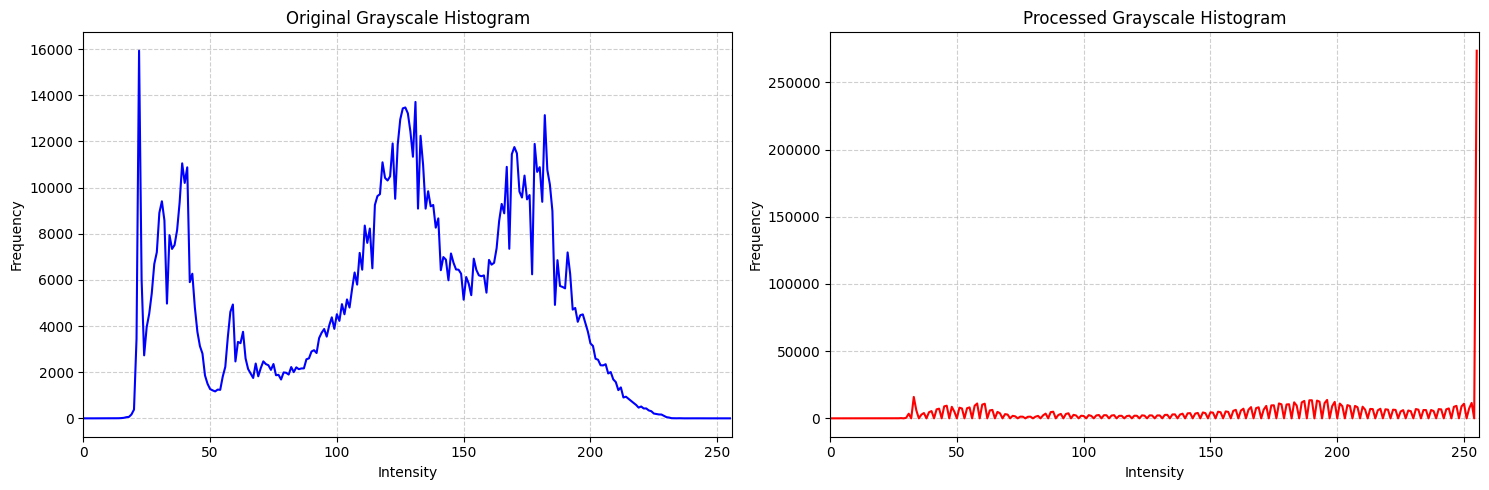

In [88]:
histg_new = cv2.calcHist([trans_img], [0], None, [256], [0, 256])

compare_histg(histg, histg_new)

Text(0.5, 1.0, 'Processed grayscale image')

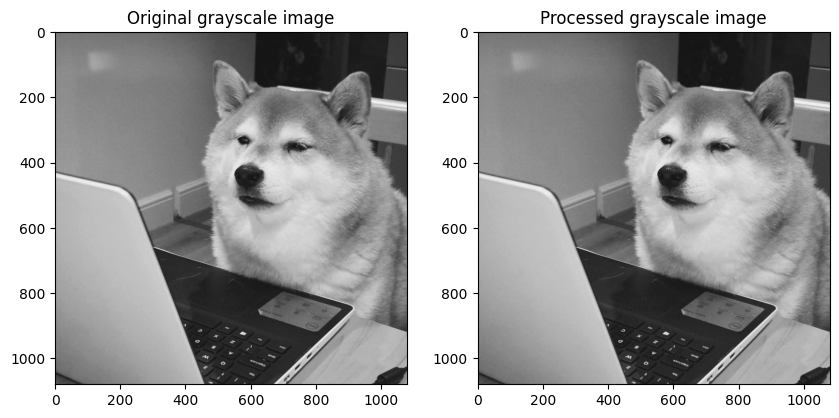

In [89]:
# a = 0.5, b = 0
trans_img = trans(image, 0.5, 0)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original grayscale image")

axes[1].imshow(trans_img, cmap="gray")
axes[1].set_title("Processed grayscale image")

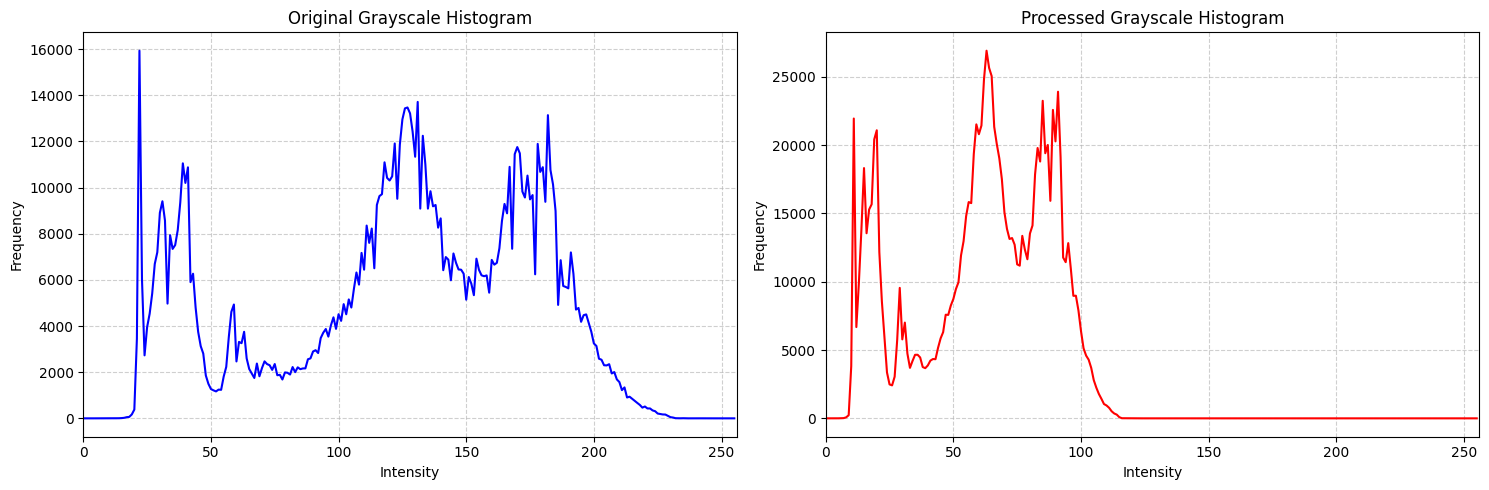

In [90]:
histg_new = cv2.calcHist([trans_img], [0], None, [256], [0, 256])

compare_histg(histg, histg_new)

## Effects of parameter a and b explanation
- Parameter b: b uniformly shifts all pixel intensities; when b < 0 the image becomes overall darker, low intensity values are compressed to 0; when b > 0 the image becomes overall brighter, high intensity values are compressed to 255.
- Parameter a: decides the contrast of the image; when a > 0, the image is not only brighter but also having higher contrast since distance between pixel intensities becomes longer; when 0 < a < 1, the image is darker and having lower contrast since distance between pixel intensities becomes shorter.

# Task B3: Image Thresholding
T = 80 or 120 or 160

In [95]:
def bw(image, t):
    bw = image.copy()
    for i in range(bw.shape[0]):
        for j in range(bw.shape[1]):
            if bw[i][j] > t:
                bw[i][j] = 255
            else:
                bw[i][j] = 0
    return bw

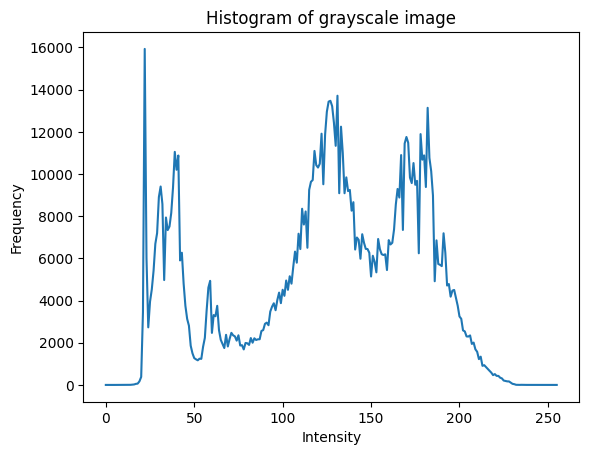

In [97]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("dog.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

histg = cv2.calcHist([image], [0], None, [256], [0, 256])
plt.plot(histg)
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.title("Histogram of grayscale image")
plt.show()

Text(0.5, 1.0, 'T = 180')

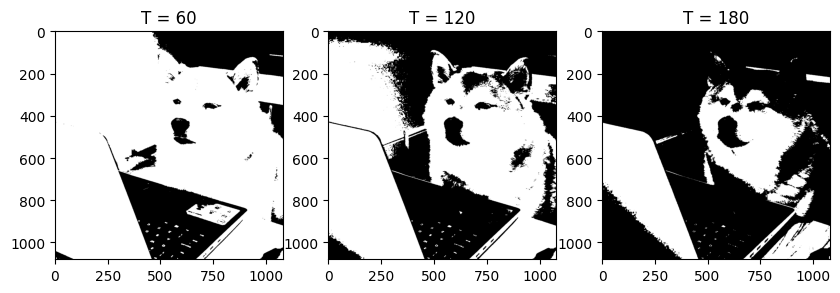

In [98]:
bw1 = bw(image, 80)
bw2 = bw(image, 120)
bw3 = bw(image, 160)

fig, axes = plt.subplots(1, 3, figsize=(10, 5))

axes[0].imshow(bw1, cmap="gray")
axes[0].set_title("T = 60")

axes[1].imshow(bw2, cmap="gray")
axes[1].set_title("T = 120")

axes[2].imshow(bw3, cmap="gray")
axes[2].set_title("T = 180")